# Phase 3 — Text Data Preparation (CRISP-DM)

Cleaning, tokenization/lemmatization, TF-IDF for Model 1, document-term matrix for Model 2 LDA, class-weight computation, and **3-class effectiveness binning** for the Model 1 comparison study.


### Handle Missing Values

Handle missing values for each model rather than globally, to avoid losing usable data unnecessarily. 

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 50
import pandas as pd

train_df = pd.read_csv('../data/drugLibTrain_raw.tsv', sep='\t')
test_df = pd.read_csv('../data/drugLibTest_raw.tsv', sep='\t')

train_df.rename(columns={'Unnamed: 0': 'reviewID'}, inplace=True)
test_df.rename(columns={'Unnamed: 0': 'reviewID'}, inplace=True)

model1_train = train_df.dropna(subset=['benefitsReview', 'effectiveness']).copy()
model1_test = test_df.dropna(subset=['benefitsReview', 'effectiveness']).copy()

model2_train = train_df.dropna(subset=['sideEffectsReview']).copy()
model2_test = test_df.dropna(subset=['sideEffectsReview']).copy()

print("Model 1 - Train rows:", len(model1_train), "| Test rows:", len(model1_test))
print("Model 2 - Train rows:", len(model2_train), "| Test rows:", len(model2_test))

Model 1 - Train rows: 3089 | Test rows: 1031
Model 2 - Train rows: 3032 | Test rows: 1013


### Text Cleaning Pipeline

Removing common stopwords (remain negation words for sentiment analysis), apply lemmetization and tokenize the words in dataset.

In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep negation words — important for sentiment/effectiveness signal
negations = {"not", "no", "nor", "n't", "never", "cannot", "can't"}
stop_words = stop_words - negations

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 2]
    return ' '.join(tokens)


model1_train['benefitsReview_clean'] = model1_train['benefitsReview'].apply(clean_text)
model1_test['benefitsReview_clean'] = model1_test['benefitsReview'].apply(clean_text)

model2_train['sideEffectsReview_clean'] = model2_train['sideEffectsReview'].apply(clean_text)
model2_test['sideEffectsReview_clean'] = model2_test['sideEffectsReview'].apply(clean_text)

# Quick before/after check
print("Model 1\nBEFORE:", model1_train['benefitsReview'].iloc[0])
print("\nAFTER:", model1_train['benefitsReview_clean'].iloc[0])

print("\n\nModel 2\nBEFORE:", model2_train['sideEffectsReview'].iloc[0])
print("\nAFTER:", model2_train['sideEffectsReview_clean'].iloc[0])

[nltk_data] Downloading package punkt to /home/ubuntu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/ubuntu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/ubuntu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/ubuntu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/ubuntu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Model 1


mangagement of congestive heart failur

AFTER: slowed progression left ventricular dysfunction overt heart failure alone agent managment hypertension mangagement congestive heart failur


Model 2
BEFORE: cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonitis, tastes disturbances , anusease anorecia , weakness fatigue insominca weakness

AFTER: cough hypotension proteinuria impotence renal failure angina pectoris tachycardia eosinophilic pneumonitis taste disturbance anusease anorecia weakness fatigue insominca weakness


### Second Removing Empty Rows Post-Cleaning

Some reviews might become empty after cleaning, double check and clean them.

In [3]:
model1_train = model1_train[model1_train['benefitsReview_clean'].str.strip() != '']
model1_test = model1_test[model1_test['benefitsReview_clean'].str.strip() != '']

model2_train = model2_train[model2_train['sideEffectsReview_clean'].str.strip() != '']
model2_test = model2_test[model2_test['sideEffectsReview_clean'].str.strip() != '']

print("Model 1 - Train rows after cleaning:", len(model1_train))
print("Model 2 - Train rows after cleaning:", len(model2_train))

Model 1 - Train rows after cleaning: 3087
Model 2 - Train rows after cleaning: 3026


### Cleaned Word Clouds (Comparison to Raw)

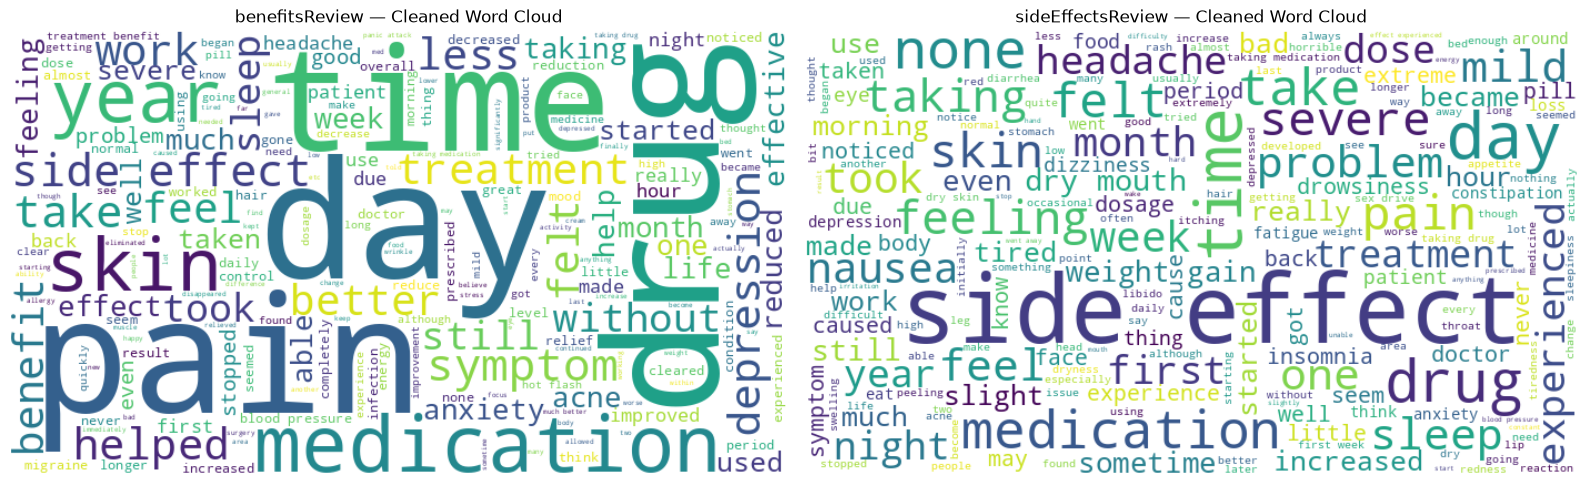

In [4]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

text1 = ' '.join(model1_train['benefitsReview_clean'].tolist())
wc1 = WordCloud(width=700, height=400, background_color='white').generate(text1)
axes[0].imshow(wc1, interpolation='bilinear')
axes[0].set_title('benefitsReview — Cleaned Word Cloud')
axes[0].axis('off')

text2 = ' '.join(model2_train['sideEffectsReview_clean'].tolist())
wc2 = WordCloud(width=700, height=400, background_color='white').generate(text2)
axes[1].imshow(wc2, interpolation='bilinear')
axes[1].set_title('sideEffectsReview — Cleaned Word Cloud')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../visuals/wordclouds_cleaned.png', dpi=150)
plt.show()

### Model 1: Preparations
#### Features Extraction - TF-IDF

Clean empty rows after extraction


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),   # unigrams + bigrams (captures phrases like "no help")
    min_df=3,             # ignore very rare terms
    max_df=0.9             # ignore overly common terms
)

X_train_tfidf = tfidf_vectorizer.fit_transform(model1_train['benefitsReview_clean'])
X_test_tfidf = tfidf_vectorizer.transform(model1_test['benefitsReview_clean'])

y_train = model1_train['effectiveness']
y_test = model1_test['effectiveness']

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (test):", X_test_tfidf.shape)

# Remove rows with all-zero TF-IDF vectors
row_sums_train = np.asarray(X_train_tfidf.sum(axis=1)).flatten()
nonzero_mask_train = row_sums_train > 0

row_sums_test = np.asarray(X_test_tfidf.sum(axis=1)).flatten()
nonzero_mask_test = row_sums_test > 0

print(f"\nRemoving {(~nonzero_mask_train).sum()} zero-vector rows from train, "
      f"{(~nonzero_mask_test).sum()} from test")

X_train_tfidf = X_train_tfidf[nonzero_mask_train]
X_test_tfidf = X_test_tfidf[nonzero_mask_test]

y_train = y_train[nonzero_mask_train]
y_test = y_test[nonzero_mask_test]

print("TF-IDF matrix shape after cleanup (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape after cleanup (test):", X_test_tfidf.shape)

TF-IDF matrix shape (train): (3087, 3000)
TF-IDF matrix shape (test): (1031, 3000)

Removing 2 zero-vector rows from train, 1 from test
TF-IDF matrix shape after cleanup (train): (3085, 3000)
TF-IDF matrix shape after cleanup (test): (1030, 3000)


#### Handle Class Imbalance

Given the class imbalance identified in Data Understanding (Highly Effective at 42.81% vs Marginally Effective at 6.02%), class weights were computed using scikit-learn's balanced weighting scheme, which will be passed directly into the classifier during Modeling rather than resampling or discarding data — preserving the full dataset and its natural class distribution while still correcting for the model's tendency to favor majority classes.

In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{'Considerably Effective': np.float64(0.6655879180151025), 'Highly Effective': np.float64(0.46495855312735496), 'Ineffective': np.float64(2.625531914893617), 'Marginally Effective': np.float64(3.39010989010989), 'Moderately Effective': np.float64(1.4903381642512077)}


#### 3-Class Effectiveness Mapping (for Model 1 comparison)

Bin the original 5-class `effectiveness` labels into High / Moderate / Low so Modeling can compare granularity vs reliability:

- **High** ← Highly Effective, Considerably Effective
- **Moderate** ← Moderately Effective
- **Low** ← Marginally Effective, Ineffective


In [7]:
EFFECTIVENESS_3CLASS_MAP = {
    'Highly Effective': 'High',
    'Considerably Effective': 'High',
    'Moderately Effective': 'Moderate',
    'Marginally Effective': 'Low',
    'Ineffective': 'Low',
}

y_train_3class = y_train.map(EFFECTIVENESS_3CLASS_MAP)
y_test_3class = y_test.map(EFFECTIVENESS_3CLASS_MAP)

print('5-class train distribution:')
print(y_train.value_counts())
print('\n3-class train distribution:')
print(y_train_3class.value_counts())
print('\n3-class test distribution:')
print(y_test_3class.value_counts())

# Balanced class weights for the 3-class scheme
classes_3 = np.unique(y_train_3class)
weights_3 = compute_class_weight('balanced', classes=classes_3, y=y_train_3class)
class_weight_dict_3class = dict(zip(classes_3, weights_3))
print('\n3-class weights:', class_weight_dict_3class)

assert y_train_3class.isna().sum() == 0, 'Unmapped 3-class labels in train'
assert y_test_3class.isna().sum() == 0, 'Unmapped 3-class labels in test'


5-class train distribution:
effectiveness
Highly Effective          1327
Considerably Effective     927
Moderately Effective       414
Ineffective                235
Marginally Effective       182
Name: count, dtype: int64

3-class train distribution:
effectiveness
High        2254
Low          417
Moderate     414
Name: count, dtype: int64

3-class test distribution:
effectiveness
High        721
Moderate    157
Low         152
Name: count, dtype: int64

3-class weights: {'High': np.float64(0.4562259686483289), 'Low': np.float64(2.466027178257394), 'Moderate': np.float64(2.4838969404186795)}


### Model 2: Preparations
#### Feature Extraction - Document-Term Matrix

Clean empty rows after extraction


In [8]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

X_topic_dtm = count_vectorizer.fit_transform(model2_train['sideEffectsReview_clean'])
print("Document-Term Matrix shape:", X_topic_dtm.shape)

# Remove documents with all-zero vectors
doc_word_counts = np.asarray(X_topic_dtm.sum(axis=1)).flatten()
nonzero_mask_topic = doc_word_counts > 0

print(f"\nRemoving {(~nonzero_mask_topic).sum()} zero-vector documents")

X_topic_dtm = X_topic_dtm[nonzero_mask_topic]
model2_train = model2_train[nonzero_mask_topic].reset_index(drop=True)

print("Document-Term Matrix shape after cleanup:", X_topic_dtm.shape)

Document-Term Matrix shape: (3026, 2000)

Removing 7 zero-vector documents
Document-Term Matrix shape after cleanup: (3019, 2000)


### Save Prepared Data

In [9]:
import scipy.sparse as sp
import pickle
from pathlib import Path

Path('../data/processed').mkdir(parents=True, exist_ok=True)

# Save sparse matrices
sp.save_npz('../data/processed/X_train_tfidf.npz', X_train_tfidf)
sp.save_npz('../data/processed/X_test_tfidf.npz', X_test_tfidf)
sp.save_npz('../data/processed/X_topic_dtm.npz', X_topic_dtm)

# Save labels (5-class and 3-class)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)
y_train_3class.to_csv('../data/processed/y_train_3class.csv', index=False)
y_test_3class.to_csv('../data/processed/y_test_3class.csv', index=False)

# Save vectorizers and class weights for reuse in Modeling notebook
with open('../data/processed/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open('../data/processed/count_vectorizer.pkl', 'wb') as f:
    pickle.dump(count_vectorizer, f)

with open('../data/processed/class_weight_dict.pkl', 'wb') as f:
    pickle.dump(class_weight_dict, f)

with open('../data/processed/class_weight_dict_3class.pkl', 'wb') as f:
    pickle.dump(class_weight_dict_3class, f)

with open('../data/processed/effectiveness_3class_map.pkl', 'wb') as f:
    pickle.dump(EFFECTIVENESS_3CLASS_MAP, f)

# Save cleaned dataframes too, for reference/traceability
model1_train.to_csv('../data/processed/model1_train_clean.csv', index=False)
model1_test.to_csv('../data/processed/model1_test_clean.csv', index=False)
model2_train.to_csv('../data/processed/model2_train_clean.csv', index=False)
model2_test.to_csv('../data/processed/model2_test_clean.csv', index=False)

print('All prepared data saved to ../data/processed/')
print('Includes 5-class and 3-class effectiveness labels.')


All prepared data saved to ../data/processed/
Includes 5-class and 3-class effectiveness labels.


### Final Sanity Check

In [10]:
### Sanity Check — Model 1 (TF-IDF)

# 1. Shape check
print("=" * 50)
print("MODEL 1 - TF-IDF SANITY CHECK")
print("=" * 50)
print("Train matrix shape:", X_train_tfidf.shape)
print("Test matrix shape:", X_test_tfidf.shape)
print("Labels (train):", y_train.shape, "| Labels (test):", y_test.shape)

# 2. Confirm row counts match between features and labels
assert X_train_tfidf.shape[0] == len(y_train), "Mismatch: train features vs labels!"
assert X_test_tfidf.shape[0] == len(y_test), "Mismatch: test features vs labels!"
print("\nRow counts match between features and labels: OK")

# 3. Vocabulary size and sample terms
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nVocabulary size:", len(feature_names))
print("Sample terms:", list(feature_names[:20]))

# 4. Check for empty rows (all-zero TF-IDF vectors — indicates a review contributed nothing)
row_sums = np.asarray(X_train_tfidf.sum(axis=1)).flatten()
empty_rows = (row_sums == 0).sum()
print(f"\nRows with all-zero TF-IDF vectors: {empty_rows} out of {X_train_tfidf.shape[0]}")

# 5. Top overall terms by summed TF-IDF weight (sanity check for meaningful vocabulary)
tfidf_sums = np.asarray(X_train_tfidf.sum(axis=0)).flatten()
top_indices = tfidf_sums.argsort()[-15:][::-1]
top_terms = [(feature_names[i], round(tfidf_sums[i], 2)) for i in top_indices]
print("\nTop 15 terms by summed TF-IDF weight:")
for term, score in top_terms:
    print(f"  {term}: {score}")

# 6. Sparsity check (how much of the matrix is zero — expected to be high for text data)
sparsity = 1.0 - (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))
print(f"\nMatrix sparsity: {sparsity:.2%}")

MODEL 1 - TF-IDF SANITY CHECK
Train matrix shape: (3085, 3000)
Test matrix shape: (1030, 3000)
Labels (train): (3085,) | Labels (test): (1030,)

Row counts match between features and labels: OK

Vocabulary size: 3000
Sample terms: ['abated', 'abdominal', 'ability', 'ability concentrate', 'ability fall', 'ability focus', 'ability sleep', 'able', 'able back', 'able breath', 'able breathe', 'able complete', 'able concentrate', 'able control', 'able cope', 'able deal', 'able eat', 'able fall', 'able feel', 'able focus']

Rows with all-zero TF-IDF vectors: 0 out of 3085

Top 15 terms by summed TF-IDF weight:
  not: 82.26
  pain: 78.34
  day: 64.2
  drug: 55.78
  benefit: 54.46
  skin: 51.67
  none: 50.35
  effect: 50.23
  taking: 49.06
  treatment: 48.64
  sleep: 47.0
  time: 46.08
  better: 45.1
  less: 44.75
  acne: 44.2

Matrix sparsity: 99.40%


In [11]:
### Sanity Check — Model 2 (Document-Term Matrix for LDA)

print("=" * 50)
print("MODEL 2 - DOCUMENT-TERM MATRIX SANITY CHECK")
print("=" * 50)
print("DTM shape:", X_topic_dtm.shape)
print("Number of documents:", model2_train.shape[0])

# 1. Confirm row counts match
assert X_topic_dtm.shape[0] == model2_train.shape[0], "Mismatch: DTM rows vs source dataframe!"
print("\nRow counts match: OK")

# 2. Vocabulary size and sample terms
topic_feature_names = count_vectorizer.get_feature_names_out()
print("\nVocabulary size:", len(topic_feature_names))
print("Sample terms:", list(topic_feature_names[:20]))

# 3. Check for empty documents (rows with zero word counts — problematic for LDA)
doc_word_counts = np.asarray(X_topic_dtm.sum(axis=1)).flatten()
empty_docs = (doc_word_counts == 0).sum()
print(f"\nDocuments with zero words after vectorization: {empty_docs} out of {X_topic_dtm.shape[0]}")

# 4. Top overall terms by raw frequency
term_freq = np.asarray(X_topic_dtm.sum(axis=0)).flatten()
top_indices = term_freq.argsort()[-15:][::-1]
top_terms = [(topic_feature_names[i], int(term_freq[i])) for i in top_indices]
print("\nTop 15 most frequent terms:")
for term, freq in top_terms:
    print(f"  {term}: {freq}")

# 5. Sparsity check
sparsity = 1.0 - (X_topic_dtm.nnz / (X_topic_dtm.shape[0] * X_topic_dtm.shape[1]))
print(f"\nMatrix sparsity: {sparsity:.2%}")

# 6. Document length distribution (words per doc after vectorization — helps assess if LDA has enough signal per doc)
print("\nWords per document (post-vectorization) stats:")
print(pd.Series(doc_word_counts).describe())

MODEL 2 - DOCUMENT-TERM MATRIX SANITY CHECK
DTM shape: (3019, 2000)
Number of documents: 3019

Row counts match: OK

Vocabulary size: 2000
Sample terms: ['abdomen', 'abdominal', 'abdominal pain', 'ability', 'able', 'able sleep', 'abnormal', 'absence', 'absolutely', 'accompanied', 'ache', 'ached', 'achieve', 'aching', 'acid', 'acid reflux', 'acne', 'act', 'active', 'activity']

Documents with zero words after vectorization: 0 out of 3019

Top 15 most frequent terms:
  effect: 1265
  side: 1219
  side effect: 1138
  not: 974
  day: 592
  taking: 537
  time: 465
  drug: 415
  also: 386
  medication: 367
  pain: 356
  skin: 347
  none: 346
  first: 330
  take: 322

Matrix sparsity: 99.22%

Words per document (post-vectorization) stats:
count    3019.000000
mean       17.425969
std        16.966855
min         1.000000
25%         6.000000
50%        13.000000
75%        24.000000
max       189.000000
dtype: float64


In [12]:
### Sanity Check — 3-class labels

print('=' * 50)
print('MODEL 1 - 3-CLASS LABEL SANITY CHECK')
print('=' * 50)
assert len(y_train_3class) == X_train_tfidf.shape[0]
assert len(y_test_3class) == X_test_tfidf.shape[0]
print('Row counts match TF-IDF matrices: OK')
print('Train 3-class value counts:')
print(y_train_3class.value_counts())
print('Mapping used:', EFFECTIVENESS_3CLASS_MAP)


MODEL 1 - 3-CLASS LABEL SANITY CHECK
Row counts match TF-IDF matrices: OK
Train 3-class value counts:
effectiveness
High        2254
Low          417
Moderate     414
Name: count, dtype: int64
Mapping used: {'Highly Effective': 'High', 'Considerably Effective': 'High', 'Moderately Effective': 'Moderate', 'Marginally Effective': 'Low', 'Ineffective': 'Low'}
